<a href="https://colab.research.google.com/github/Howida-Ashraf/Thyroid-Prediction/blob/main/pattern_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder, StandardScaler

from imblearn.over_sampling import SMOTE

from sklearn.model_selection import train_test_split

import warnings
warnings.filterwarnings('ignore')

In [ ]:

df = pd.read_csv(r"C:\Users\COMPUMARTS\Desktop\pattern 3\thyroidDF.csv")
df.head(10)

,age,sex,on_thyroxine,query_on_thyroxine,on_antithyroid_meds,sick,pregnant,thyroid_surgery,I131_treatment,query_hypothyroid,...,TT4,T4U_measured,T4U,FTI_measured,FTI,TBG_measured,TBG,referral_source,target,patient_id
0,29,F,f,f,f,f,f,f,f,t,...,NaN,f,NaN,f,NaN,f,NaN,other,-,840801013
1,29,F,f,f,f,f,f,f,f,f,...,128.0,f,NaN,f,NaN,f,NaN,other,-,840801014
2,41,F,f,f,f,f,f,f,f,f,...,NaN,f,NaN,f,NaN,t,11.0,other,-,840801042
3,36,F,f,f,f,f,f,f,f,f,...,NaN,f,NaN,f,NaN,t,26.0,other,-,840803046
4,32,F,f,f,f,f,f,f,f,f,...,NaN,f,NaN,f,NaN,t,36.0,other,S,840803047
5,60,F,f,f,f,f,f,f,f,f,...,NaN,f,NaN,f,NaN,t,26.0,other,-,840803048
6,77,F,f,f,f,f,f,f,f,f,...,NaN,f,NaN,f,NaN,t,21.0,other,-,840803068
7,28,F,f,f,f,f,f,f,f,f,...,116.0,f,NaN,f,NaN,f,NaN,SVI,-,840807019
8,28,F,f,f,f,f,f,f,f,f,...,76.0,f,NaN,f,NaN,f,NaN,other,-,840808060
9,28,F,f,f,f,f,f,f,f,f,...,83.0,f,NaN,f,NaN,f,NaN,other,-,840808073


In [ ]:
# Analyze combined disease labels
df['target'] = df['target'].astype(str)

combo_targets = df[df['target'].str.len() > 1]

print("Combined Disease Labels:")
print(combo_targets['target'].value_counts())

print("\nTotal Combination Samples:", len(combo_targets))

Combined Disease Labels:
target
GK     49
AK     46
MK     16
C|I    12
KJ     11
GI     10
H|K     8
FK      6
MI      2
LJ      1
GKJ     1
OI      1
D|R     1
Name: count, dtype: int64

Total Combination Samples: 164


In [ ]:
disease_mapping = {
    '-': 'Normal',
    'A': 'Hyperthyroid',
    'B': 'T3 Toxic',
    'C': 'Toxic Goitre',
    'D': 'Secondary Toxic',
    'E': 'Hypothyroid',
    'F': 'Primary Hypothyroid',
    'G': 'Compensated Hypothyroid',
    'H': 'Secondary Hypothyroid',
    'I': 'Increased Binding Protein',
    'J': 'Decreased Binding Protein',
    'K': 'Non-thyroidal Illness',
    'L': 'Replacement Therapy',
    'M': 'Underreplaced',
    'N': 'Overreplaced',
    'O': 'Antithyroid Drugs',
    'P': 'I131 Treatment',
    'Q': 'Surgery',
    'R': 'Discordant Assay Results',
    'S': 'Elevated TBG',
    'T': 'Elevated Thyroid Hormones'
}

In [ ]:
combo_mapping = {
    'AK': 'Hyperthyroid + Non-thyroidal Illness',
    'GK': 'Compensated Hypothyroid + Non-thyroidal Illness',
    'MK': 'Underreplaced + Non-thyroidal Illness',
    'KJ': 'Non-thyroidal Illness + Decreased Binding Protein',
    'GI': 'Compensated Hypothyroid + Increased Binding Protein',
    'C|I': 'Toxic Goitre + Increased Binding Protein',
    'H|K': 'Secondary Hypothyroid + Non-thyroidal Illness',
    'FK': 'Primary Hypothyroid + Non-thyroidal Illness',
    'MI': 'Underreplaced + Increased Binding Protein',
    'LJ': 'Replacement Therapy + Decreased Binding Protein',
    'GKJ': 'Compensated Hypothyroid + Non-thyroidal Illness + Decreased Binding Protein',
    'OI': 'Antithyroid Drugs + Increased Binding Protein',
    'D|R': 'Secondary Toxic + Discordant Assay Results'
}

In [ ]:
df['target'] = df['target'].replace(combo_mapping)
df['target'] = df['target'].replace(disease_mapping)

# Removed because they contain diseases
# that cannot be reliably identified
# using thyroid laboratory tests alone

remove_codes = [
    'Hyperthyroid + Non-thyroidal Illness',
    'Compensated Hypothyroid + Non-thyroidal Illness',
    'Underreplaced + Non-thyroidal Illness',
    'Non-thyroidal Illness + Decreased Binding Protein',
    'Compensated Hypothyroid + Increased Binding Protein',
    'Toxic Goitre + Increased Binding Protein'
]

df = df[~df['target'].isin(remove_codes)]

In [ ]:
remove_classes = [
    'Discordant Assay Results',
     'Increased Binding Protein',
    'Decreased Binding Protein',
        'Elevated TBG',

    'Non-thyroidal Illness'
]

df = df[~df['target'].isin(remove_classes)]

In [ ]:
# Dataset overview after medical filtering

print("Dataset Shape:")
print(df.shape)

print("\nNumber of Features:", df.shape[1] - 1)
print("Number of Samples:", df.shape[0])

print("\nTarget Classes:")
print(df['target'].value_counts())

Dataset Shape:
(7935, 31)

Number of Features: 30
Number of Samples: 7935

Target Classes:
target
Normal                                                                         6771
Compensated Hypothyroid                                                         359
Primary Hypothyroid                                                             233
Hyperthyroid                                                                    147
Replacement Therapy                                                             115
Underreplaced                                                                   111
Overreplaced                                                                    110
T3 Toxic                                                                         21
Surgery                                                                          14
Antithyroid Drugs                                                                14
Secondary Toxic                                               

In [ ]:
# Display dataset information

print("\nColumn Names:")
print(df.columns.tolist())

print("\nDataset Information:")
df.info()


Column Names:
['age', 'sex', 'on_thyroxine', 'query_on_thyroxine', 'on_antithyroid_meds', 'sick', 'pregnant', 'thyroid_surgery', 'I131_treatment', 'query_hypothyroid', 'query_hyperthyroid', 'lithium', 'goitre', 'tumor', 'hypopituitary', 'psych', 'TSH_measured', 'TSH', 'T3_measured', 'T3', 'TT4_measured', 'TT4', 'T4U_measured', 'T4U', 'FTI_measured', 'FTI', 'TBG_measured', 'TBG', 'referral_source', 'target', 'patient_id']

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
Index: 7935 entries, 0 to 9171
Data columns (total 31 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   age                  7935 non-null   int64  
 1   sex                  7678 non-null   object 
 2   on_thyroxine         7935 non-null   object 
 3   query_on_thyroxine   7935 non-null   object 
 4   on_antithyroid_meds  7935 non-null   object 
 5   sick                 7935 non-null   object 
 6   pregnant             7935 non-null   object 


In [ ]:
# Missing values analysis

missing_values = df.isnull().sum()
missing_values = missing_values[missing_values > 0]

print("Missing Values Per Column:")
print(missing_values.sort_values(ascending=False))

Missing Values Per Column:
TBG    7674
T3     2346
TSH     730
T4U     693
FTI     686
TT4     355
sex     257
dtype: int64


In [ ]:
duplicate_rows = df.duplicated().sum()

print("Number of Duplicate Rows:", duplicate_rows)

Number of Duplicate Rows: 0


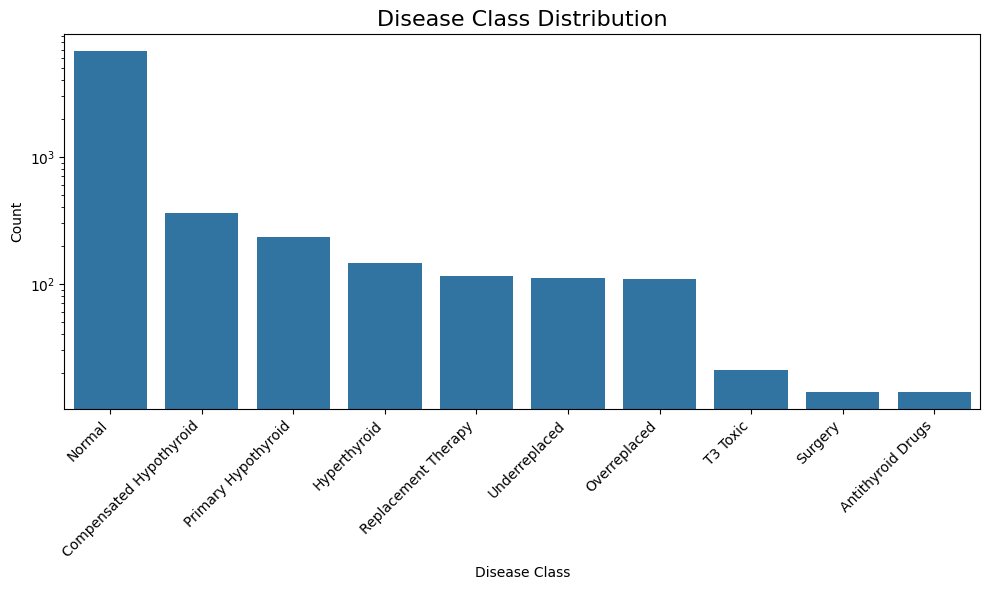

In [ ]:
class_counts = df['target'].value_counts()

filtered_counts = class_counts[class_counts > 10]

plt.figure(figsize=(10,6))

sns.barplot(
    x=filtered_counts.index,
    y=filtered_counts.values
)

plt.title("Disease Class Distribution", fontsize=16)

plt.xlabel("Disease Class")
plt.ylabel("Count")

plt.xticks(rotation=45, ha='right')

plt.yscale('log')

plt.tight_layout()
plt.show()

In [ ]:

num_cols = df.select_dtypes(include=['int64', 'float64']).columns
cat_cols = df.select_dtypes(include=['object']).columns

num_imputer = SimpleImputer(strategy='median')
df[num_cols] = num_imputer.fit_transform(df[num_cols])

cat_imputer = SimpleImputer(strategy='most_frequent')
if len(cat_cols) > 0:
    cat_imputer = SimpleImputer(strategy='most_frequent')
    df[cat_cols] = cat_imputer.fit_transform(df[cat_cols])

print(df.isnull().sum().sum())

0


In [ ]:

label_encoders = {}

for col in cat_cols:
    if col!='target':
        le = LabelEncoder()
        df[col] = le.fit_transform(df[col].astype(str))
        label_encoders[col] = le

print(df.head())

    age  sex  on_thyroxine  query_on_thyroxine  on_antithyroid_meds  sick  \
0  29.0    0             0                   0                    0     0   
1  29.0    0             0                   0                    0     0   
2  41.0    0             0                   0                    0     0   
3  36.0    0             0                   0                    0     0   
5  60.0    0             0                   0                    0     0   

   pregnant  thyroid_surgery  I131_treatment  query_hypothyroid  ...    TT4  \
0         0                0               0                  1  ...  104.0   
1         0                0               0                  0  ...  128.0   
2         0                0               0                  0  ...  104.0   
3         0                0               0                  0  ...  104.0   
5         0                0               0                  0  ...  104.0   

   T4U_measured   T4U  FTI_measured    FTI  TBG_measured   TBG

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

if 'patient_id' in df.columns:
    df.drop("patient_id", axis=1, inplace=True)

class_counts = df['target'].value_counts()

valid_classes = class_counts[class_counts > 10].index
df = df[df['target'].isin(valid_classes)]


target_encoder = LabelEncoder()
df['target'] = target_encoder.fit_transform(df['target'])

X = df.drop('target', axis=1)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(
    sampling_strategy='not majority',
    random_state=42,
    k_neighbors=2
)
X_train, y_train = smote.fit_resample(X_train, y_train)

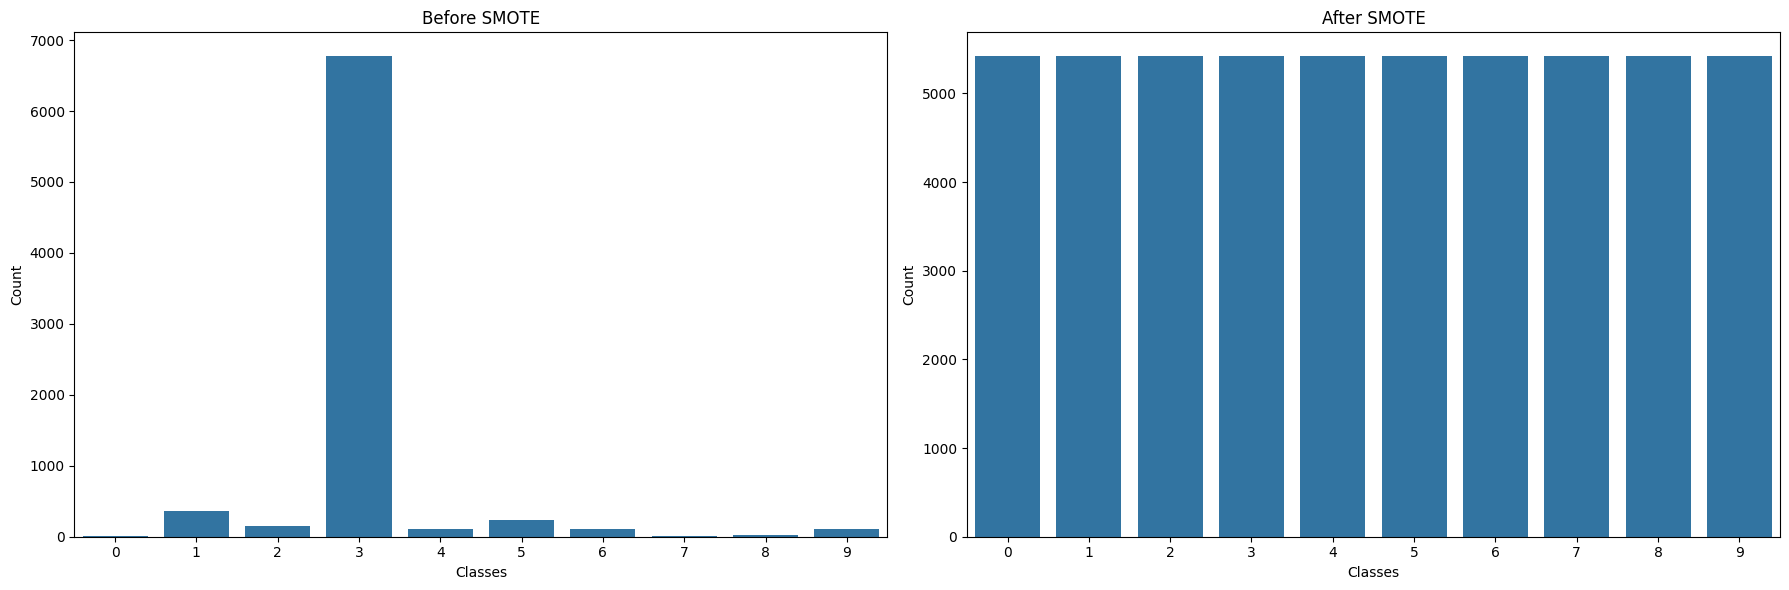

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(18,6))

# Before SMOTE
sns.countplot(x=y, ax=axes[0])

axes[0].set_title("Before SMOTE")
axes[0].set_xlabel("Classes")
axes[0].set_ylabel("Count")

# After SMOTE
sns.countplot(x=y_train, ax=axes[1])

axes[1].set_title("After SMOTE")
axes[1].set_xlabel("Classes")
axes[1].set_ylabel("Count")

plt.tight_layout()

plt.show()

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

lr_model = LogisticRegression(max_iter=500)

lr_model.fit(X_train, y_train)

lr_pred = lr_model.predict(X_test)

lr_acc = accuracy_score(y_test, lr_pred)

print("Logistic Regression Accuracy:", lr_acc)

Logistic Regression Accuracy: 0.9138695376820772


In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

rf_acc = accuracy_score(y_test, rf_pred)

print("Random Forest Accuracy:", rf_acc)

Random Forest Accuracy: 0.9791006966434452


In [ ]:
from sklearn.svm import SVC

svm_model = SVC()

svm_model.fit(X_train, y_train)

svm_pred = svm_model.predict(X_test)

svm_acc = accuracy_score(y_test, svm_pred)

print("SVM Accuracy:", svm_acc)

SVM Accuracy: 0.8923369221025966


In [ ]:
from xgboost import XGBClassifier

best_model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='mlogloss',
)

best_model.fit(
    X_train,
    y_train,
    eval_set=[(X_train, y_train), (X_test, y_test)],
    verbose=False
)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softprob'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes fr

In [ ]:

y_pred = best_model.predict(X_test)

predicted_diseases = target_encoder.inverse_transform(y_pred)
actual_diseases = target_encoder.inverse_transform(y_test)
comparison = pd.DataFrame({
    'Actual Disease': actual_diseases,
    'Predicted Disease': predicted_diseases
})
print(comparison.head(10))

            Actual Disease        Predicted Disease
0                   Normal                   Normal
1                   Normal                   Normal
2            Underreplaced            Underreplaced
3                   Normal                   Normal
4                   Normal                   Normal
5                   Normal                   Normal
6                   Normal                   Normal
7                   Normal                   Normal
8                   Normal                   Normal
9  Compensated Hypothyroid  Compensated Hypothyroid


In [ ]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Test Accuracy =", accuracy * 100, "%")

Test Accuracy = 98.16339455351488 %


In [ ]:
import joblib

joblib.dump(best_model, "thyroid_xgboost_model.pkl")

print("Model Saved Successfully!")

Model Saved Successfully!


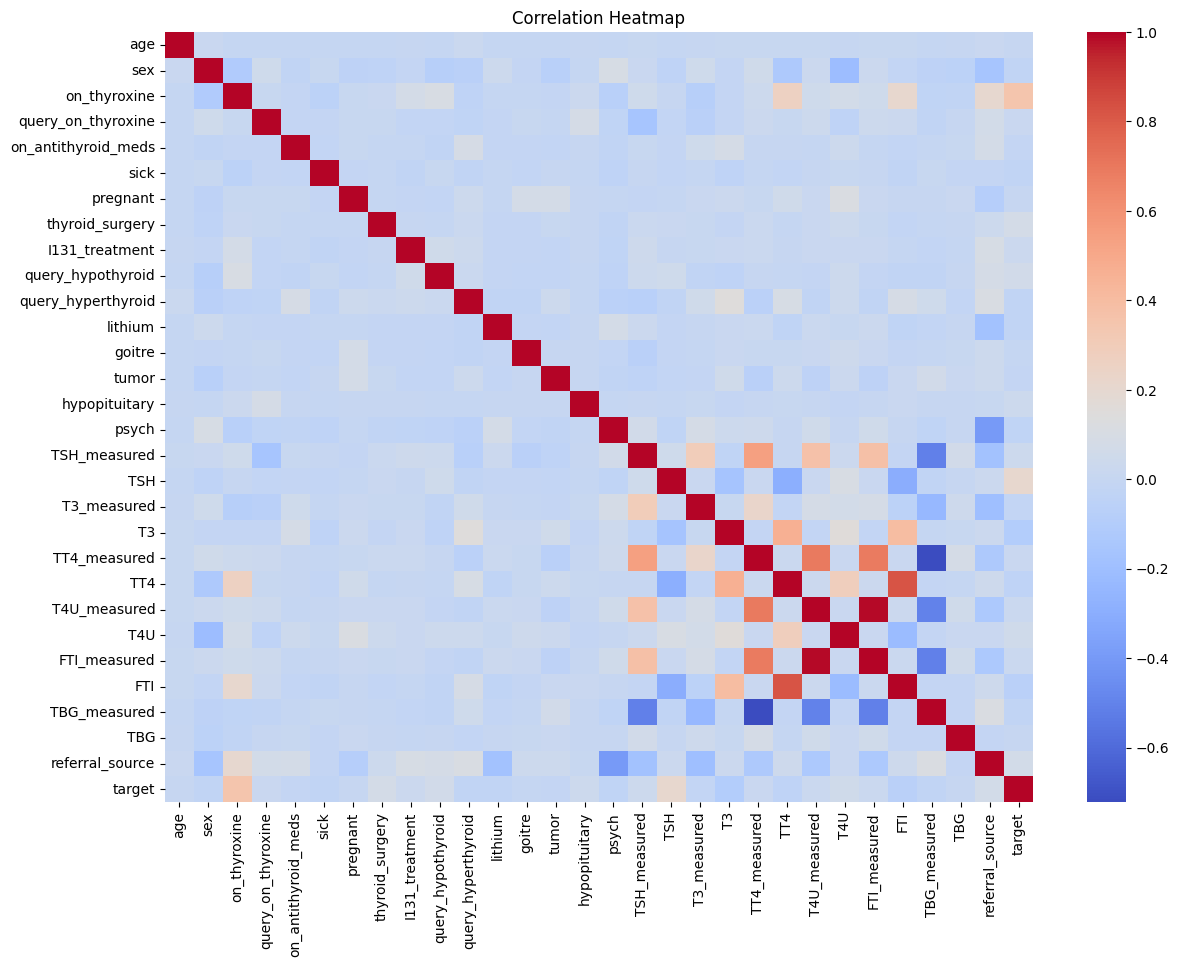

In [ ]:
plt.figure(figsize=(14,10))

corr = df.corr()

sns.heatmap(corr, cmap='coolwarm')

plt.title("Correlation Heatmap")

plt.show()

In [ ]:
from sklearn.metrics import classification_report

class_names = target_encoder.classes_

print(
    classification_report(
        y_test,
        y_pred,
        target_names=class_names
    )
)

                         precision    recall  f1-score   support

      Antithyroid Drugs       1.00      0.67      0.80         3
Compensated Hypothyroid       0.95      1.00      0.97        72
           Hyperthyroid       0.87      0.93      0.90        29
                 Normal       1.00      0.99      0.99      1354
           Overreplaced       0.93      0.64      0.76        22
    Primary Hypothyroid       0.98      0.96      0.97        47
    Replacement Therapy       0.66      0.91      0.76        23
                Surgery       1.00      0.67      0.80         3
               T3 Toxic       0.80      1.00      0.89         4
          Underreplaced       0.96      1.00      0.98        22

               accuracy                           0.98      1579
              macro avg       0.91      0.88      0.88      1579
           weighted avg       0.98      0.98      0.98      1579



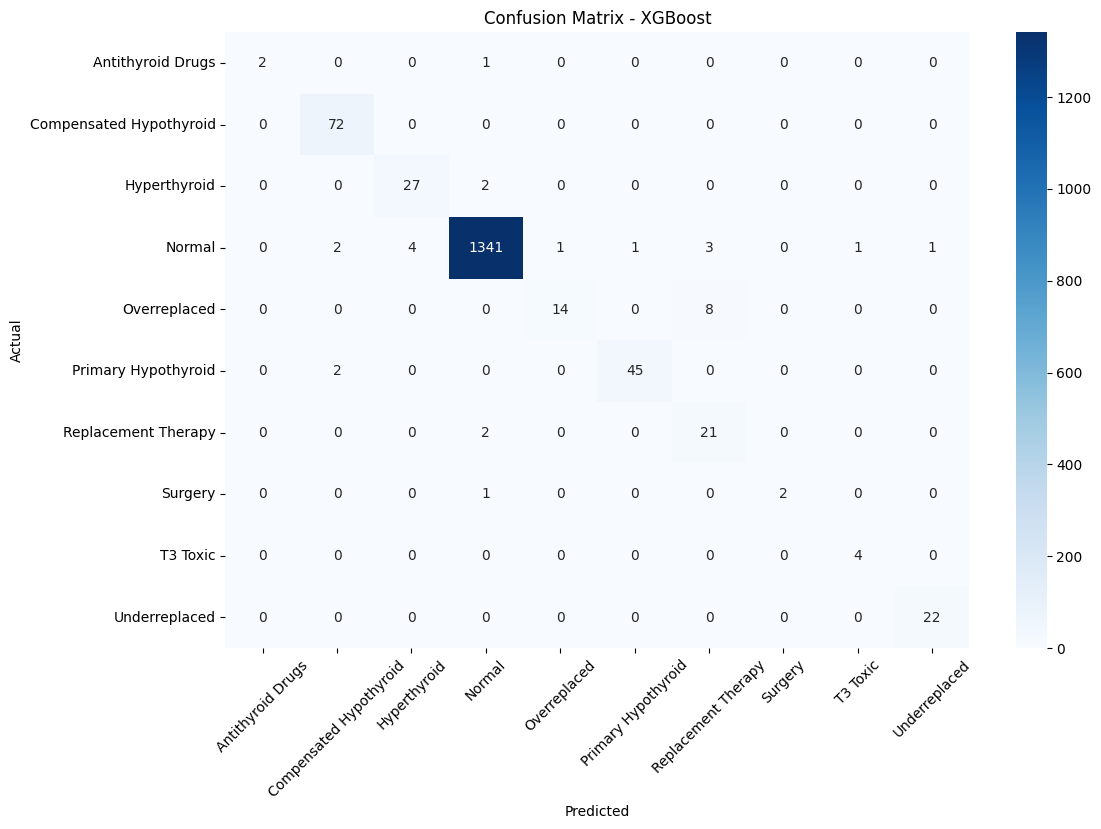

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

class_names = target_encoder.classes_

plt.figure(figsize=(12,8))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("Confusion Matrix - XGBoost")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.xticks(rotation=45)
plt.yticks(rotation=0)

plt.show()

In [ ]:
importance = best_model.feature_importances_

feature_names = X.columns

feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importance
})

feature_importance_df = feature_importance_df.sort_values(
    by='Importance',
    ascending=False
)

print(feature_importance_df)

                Feature  Importance
7       thyroid_surgery    0.222622
4   on_antithyroid_meds    0.179283
2          on_thyroxine    0.177190
25                  FTI    0.068193
17                  TSH    0.057541
21                  TT4    0.048991
19                   T3    0.039431
10   query_hyperthyroid    0.027862
20         TT4_measured    0.020272
12               goitre    0.019928
3    query_on_thyroxine    0.019830
28      referral_source    0.014423
22         T4U_measured    0.013305
18          T3_measured    0.010967
16         TSH_measured    0.010942
8        I131_treatment    0.010716
14        hypopituitary    0.008550
26         TBG_measured    0.007659
24         FTI_measured    0.006555
9     query_hypothyroid    0.006494
23                  T4U    0.005925
1                   sex    0.005819
0                   age    0.004863
27                  TBG    0.004603
5                  sick    0.002356
6              pregnant    0.002300
13                tumor    0

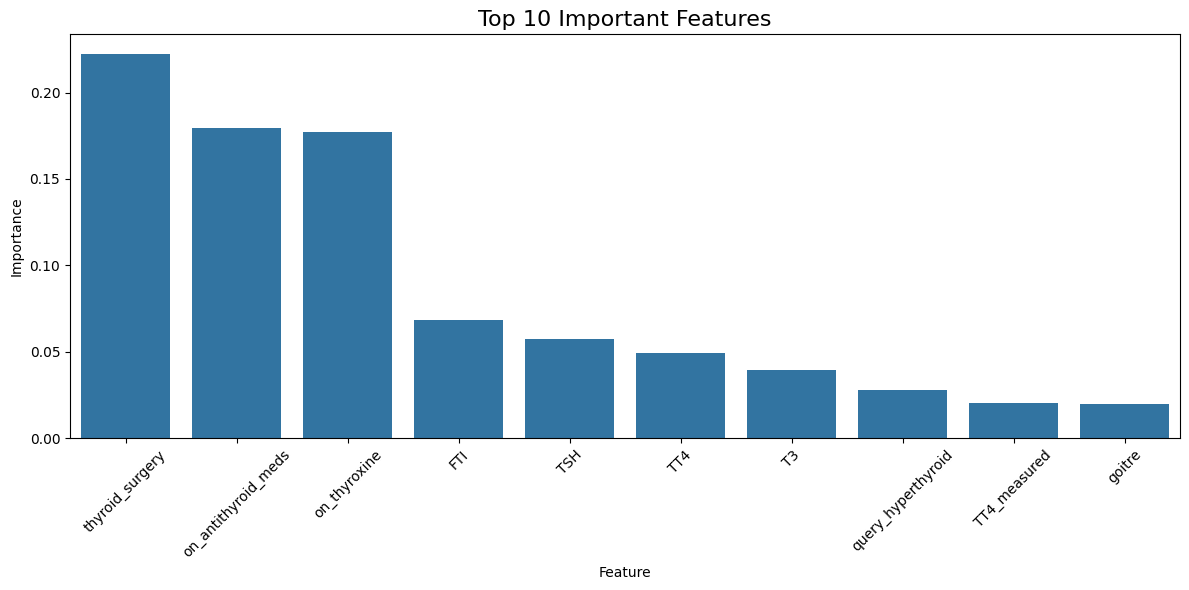

In [ ]:
top_features = feature_importance_df.head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    data=top_features,
    x='Feature',
    y='Importance'
)

plt.title("Top 10 Important Features", fontsize=16)

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

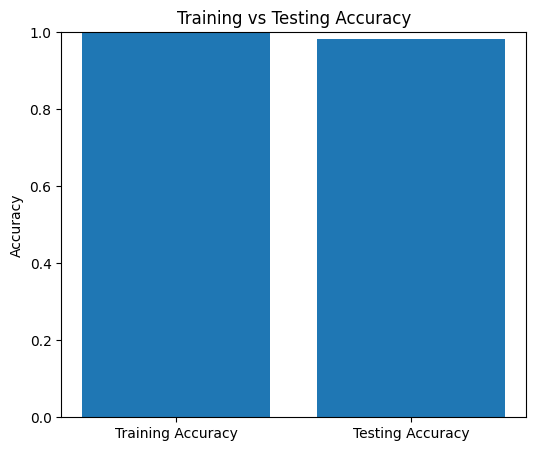

Training Accuracy: 0.9999630791951265
Testing Accuracy: 0.9816339455351488


In [ ]:
from sklearn.metrics import accuracy_score

train_pred = best_model.predict(X_train)
train_acc = accuracy_score(y_train, train_pred)

test_pred =best_model.predict(X_test)
test_acc = accuracy_score(y_test, test_pred)

plt.figure(figsize=(6,5))

plt.bar(
    ['Training Accuracy', 'Testing Accuracy'],
    [train_acc, test_acc]
)

plt.ylim(0,1)

plt.title("Training vs Testing Accuracy")

plt.ylabel("Accuracy")

plt.show()

print("Training Accuracy:", train_acc)
print("Testing Accuracy:", test_acc)

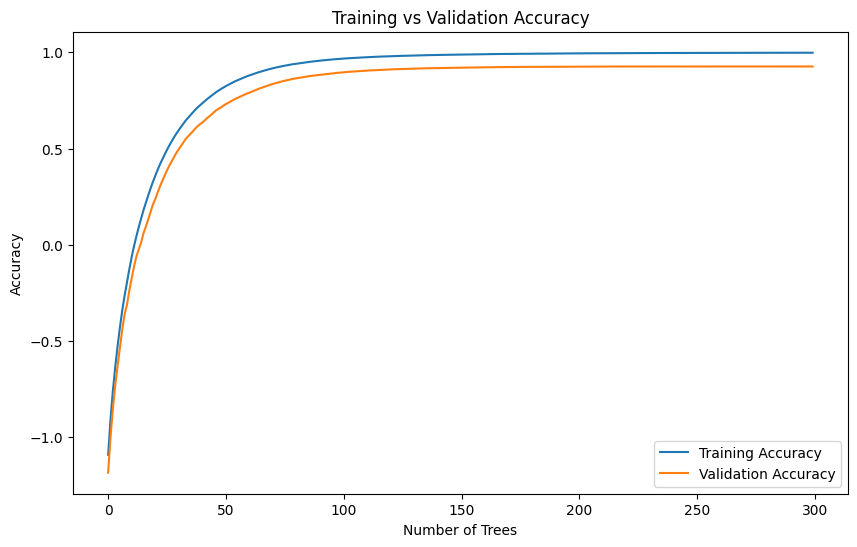

In [ ]:
results = best_model.evals_result()

train_acc = [1 - x for x in results['validation_0']['mlogloss']]
val_acc = [1 - x for x in results['validation_1']['mlogloss']]

plt.figure(figsize=(10,6))

plt.plot(train_acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')

plt.xlabel("Number of Trees")
plt.ylabel("Accuracy")

plt.title("Training vs Validation Accuracy")

plt.legend()

plt.show()

In [ ]:
import random

for _ in range(10):

    i = random.randint(0, len(X_test)-1)

    sample = X_test[i].reshape(1, -1)

    prediction = best_model.predict(sample)

    predicted_disease = target_encoder.inverse_transform(prediction)[0]

    actual_disease = target_encoder.inverse_transform([y_test.iloc[i]])[0]

    print("=" * 50)

    print(f"Sample Index       : {i}")
    print(f"Actual Disease     : {actual_disease}")
    print(f"Predicted Disease  : {predicted_disease}")

    if actual_disease == predicted_disease:
        print("Prediction Status  : Correct")
    else:
        print("Prediction Status  : Wrong")

Sample Index       : 1309
Actual Disease     : Normal
Predicted Disease  : Normal
Prediction Status  : Correct
Sample Index       : 597
Actual Disease     : Normal
Predicted Disease  : Normal
Prediction Status  : Correct
Sample Index       : 748
Actual Disease     : Normal
Predicted Disease  : Normal
Prediction Status  : Correct
Sample Index       : 1056
Actual Disease     : Normal
Predicted Disease  : Normal
Prediction Status  : Correct
Sample Index       : 1444
Actual Disease     : Hyperthyroid
Predicted Disease  : Hyperthyroid
Prediction Status  : Correct
Sample Index       : 369
Actual Disease     : Normal
Predicted Disease  : Normal
Prediction Status  : Correct
Sample Index       : 1058
Actual Disease     : Normal
Predicted Disease  : Normal
Prediction Status  : Correct
Sample Index       : 263
Actual Disease     : Normal
Predicted Disease  : Normal
Prediction Status  : Correct
Sample Index       : 365
Actual Disease     : Normal
Predicted Disease  : Normal
Prediction Status  : Co

In [ ]:
comparison_df = pd.DataFrame({

    'Model': [
        'Logistic Regression',
        'Random Forest',
        'SVM',
        'XGBoost'
    ],

    'Accuracy': [
        lr_acc,
        rf_acc,
        svm_acc,
        accuracy
    ]
})

print(comparison_df)

                 Model  Accuracy
0  Logistic Regression  0.913870
1        Random Forest  0.979101
2                  SVM  0.892337
3              XGBoost  0.981634


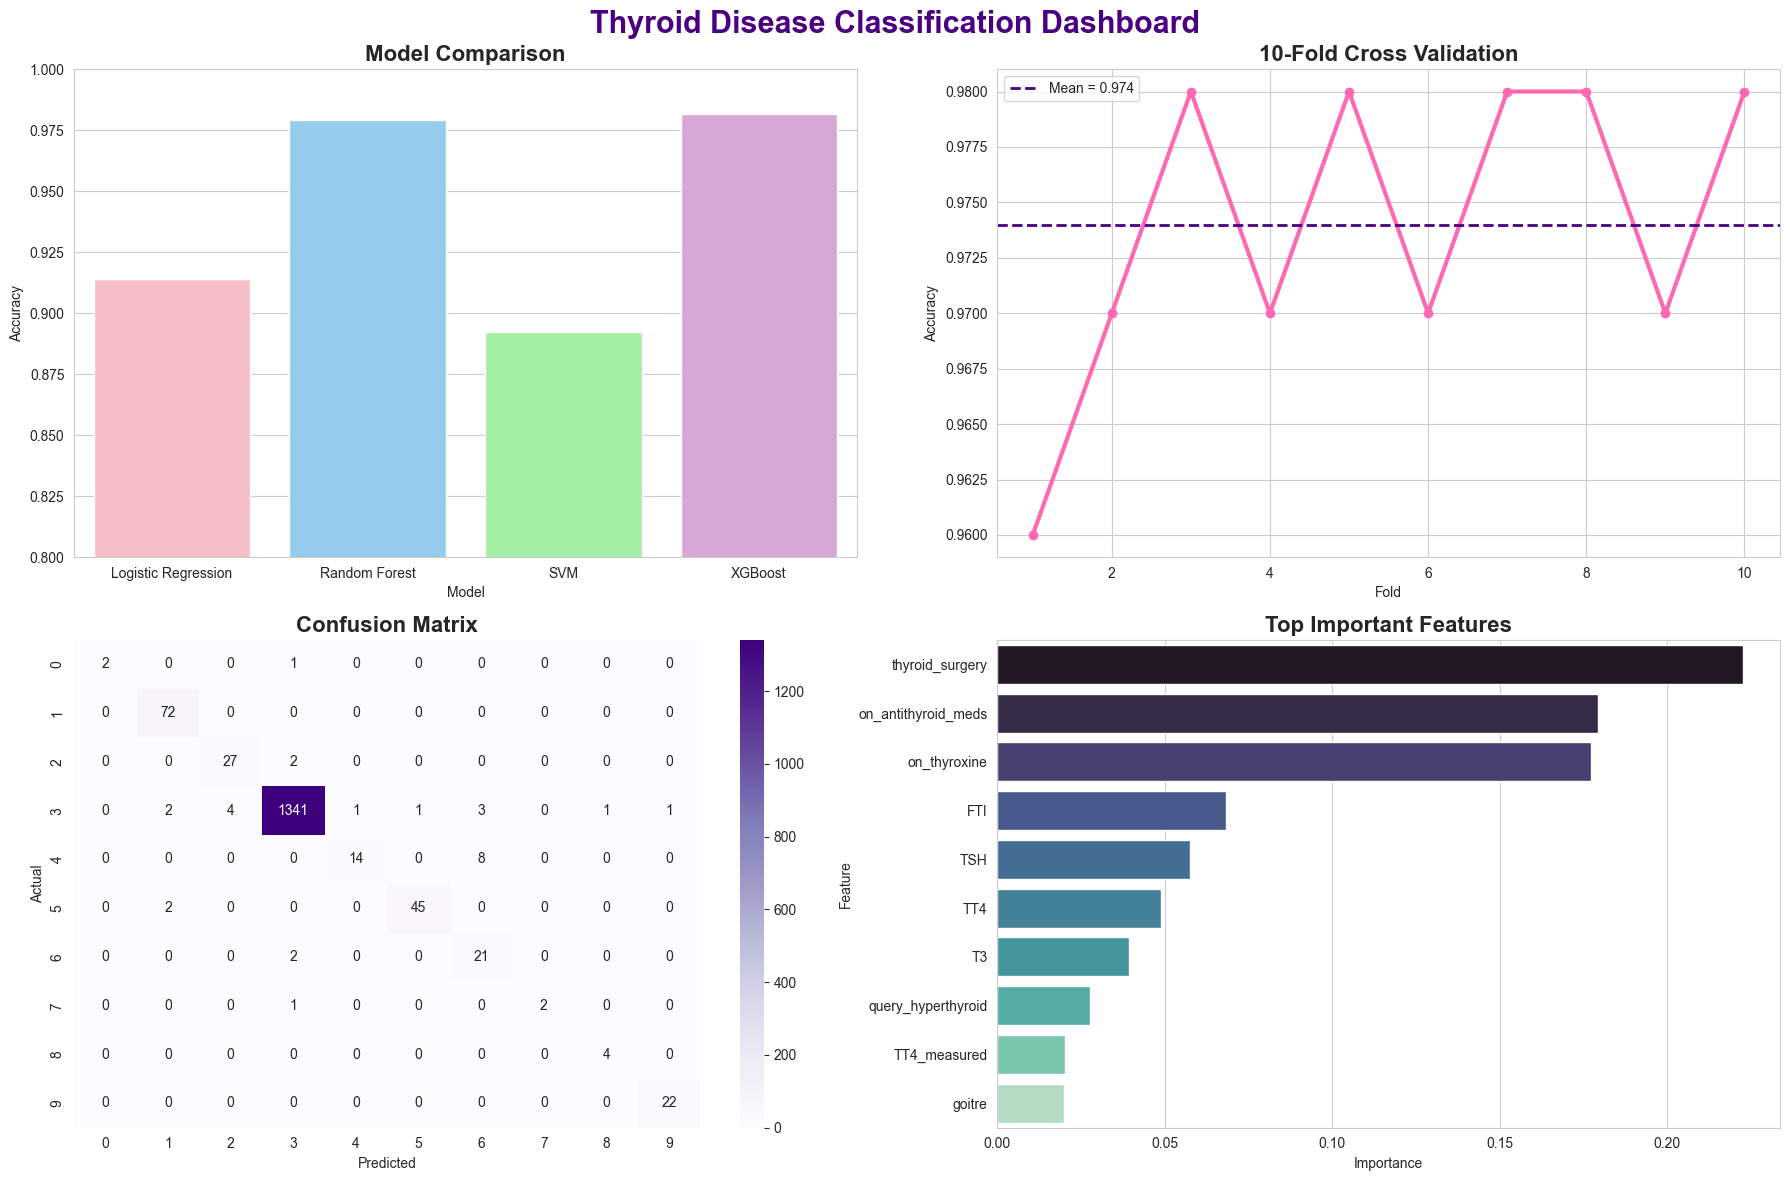

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

sns.set_style("whitegrid")

# =========================
# البيانات
# =========================

models_data = {
    'Logistic Regression': lr_acc,
    'Random Forest': rf_acc,
    'SVM': svm_acc,
    'XGBoost': accuracy
}

results_df = pd.DataFrame(
    list(models_data.items()),
    columns=['Model', 'Accuracy']
)

cv_scores = [0.96, 0.97, 0.98, 0.97, 0.98,
             0.97, 0.98, 0.98, 0.97, 0.98]

cv_mean = np.mean(cv_scores)

# =========================
# الشكل الرئيسي
# =========================

fig, axes = plt.subplots(2, 2, figsize=(18, 12))

fig.suptitle(
    'Thyroid Disease Classification Dashboard',
    fontsize=22,
    fontweight='bold',
    color='#4B0082'
)

# ====================================
# 1) Model Comparison
# ====================================

model_colors = ['#FFB6C1', '#87CEFA', '#98FB98', '#DDA0DD']

sns.barplot(
    x='Model',
    y='Accuracy',
    data=results_df,
    palette=model_colors,
    ax=axes[0,0]
)

axes[0,0].set_title(
    'Model Comparison',
    fontsize=16,
    fontweight='bold'
)

axes[0,0].set_ylim(0.8, 1)

# ====================================
# 2) Cross Validation
# ====================================

axes[0,1].plot(
    range(1,11),
    cv_scores,
    marker='o',
    linewidth=3,
    color='#FF69B4'
)

axes[0,1].axhline(
    y=cv_mean,
    linestyle='--',
    linewidth=2,
    color='#4B0082',
    label=f'Mean = {cv_mean:.3f}'
)

axes[0,1].set_title(
    '10-Fold Cross Validation',
    fontsize=16,
    fontweight='bold'
)

axes[0,1].set_xlabel('Fold')
axes[0,1].set_ylabel('Accuracy')
axes[0,1].legend()

# ====================================
# 3) Confusion Matrix
# ====================================

from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Purples',
    ax=axes[1,0]
)

axes[1,0].set_title(
    'Confusion Matrix',
    fontsize=16,
    fontweight='bold'
)

axes[1,0].set_xlabel('Predicted')
axes[1,0].set_ylabel('Actual')

# ====================================
# 4) Feature Importance
# ====================================

top_features = feature_importance_df.head(10)

sns.barplot(
    data=top_features,
    x='Importance',
    y='Feature',
    palette='mako',
    ax=axes[1,1]
)

axes[1,1].set_title(
    'Top Important Features',
    fontsize=16,
    fontweight='bold'
)

# ====================================

plt.tight_layout()

plt.show()

In [ ]:
import random
import gradio as gr
import pandas as pd
import numpy as np

# =========================================
# Random Prediction Function
# =========================================

def random_prediction():

    i = random.randint(0, len(X_test)-1)

    sample = X_test[i].reshape(1, -1)

    prediction = best_model.predict(sample)

    predicted_disease = target_encoder.inverse_transform(prediction)[0]

    actual_disease = target_encoder.inverse_transform(
        [y_test.iloc[i]]
    )[0]

    status = "✅ Correct Prediction" \
        if predicted_disease == actual_disease \
        else "❌ Wrong Prediction"

    result = f"""
# 🩺 Thyroid Disease Prediction

### 📌 Sample Index:
{i}

### 🔬 Actual Disease:
{actual_disease}

### 🤖 Predicted Disease:
{predicted_disease}

### 🎯 Result:
{status}
"""

    return result

# =========================================
# GUI
# =========================================

with gr.Blocks(theme=gr.themes.Soft()) as demo:

    gr.Markdown("""
    # 🩺 Thyroid Disease AI Demo

    ### Random Medical Prediction System
    """)

    output = gr.Markdown()

    btn = gr.Button(
        "🎲 Generate Random Prediction",
        size="lg"
    )

    btn.click(
        fn=random_prediction,
        outputs=output
    )

demo.launch()

* Running on local URL:  http://127.0.0.1:7860
* To create a public link, set `share=True` in `launch()`.
